# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech - Jaya Jaya Institut

- Nama: Nurya Fahru Rosyidin
- Email: nurya.fahrurosyidin@gmail.com
- Id Dicoding: nuryafahrurosyidin

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from getpass import getpass

### Menyiapkan data yang akan digunakan

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset dari repository Github
# url = "https://raw.githubusercontent.com/NuryaFahruRosyidin2406/Submission-Akhir-Dicoding-Menyelesaikan-Permasalahan-Institusi-Pendidikan/refs/heads/main/Dataset/students_performance/data.csv?token=GHSAT0AAAAAAEIQKDBDDAYP2WGJBY46QJ5M2VOCH2A"
url = "/content/drive/MyDrive/Colab_Notebooks/Dataset/Submission_Akhir_Dicoding_Performa_Siswa/students_performance/data.csv"
# df = pd.read_csv(url, encoding='windows-1252')
df = pd.read_csv(url)
df.head()

,Marital_status;Application_mode;Application_order;Course;Daytime_evening_attendance;Previous_qualification;Previous_qualification_grade;Nacionality;Mothers_qualification;Fathers_qualification;Mothers_occupation;Fathers_occupation;Admission_grade;Displaced;Educational_special_needs;Debtor;Tuition_fees_up_to_date;Gender;Scholarship_holder;Age_at_enrollment;International;Curricular_units_1st_sem_credited;Curricular_units_1st_sem_enrolled;Curricular_units_1st_sem_evaluations;Curricular_units_1st_sem_approved;Curricular_units_1st_sem_grade;Curricular_units_1st_sem_without_evaluations;Curricular_units_2nd_sem_credited;Curricular_units_2nd_sem_enrolled;Curricular_units_2nd_sem_evaluations;Curricular_units_2nd_sem_approved;Curricular_units_2nd_sem_grade;Curricular_units_2nd_sem_without_evaluations;Unemployment_rate;Inflation_rate;GDP;Status
0,1;17;5;171;1;1;122.0;1;19;12;5;9;127.3;1;0;0;1...
1,1;15;1;9254;1;1;160.0;1;1;3;3;3;142.5;1;0;0;0;...
2,1;1;5;9070;1;1;122.0;1;37;37;9;9;124.8;1;0;0;0...
3,1;17;2;9773;1;1;122.0;1;38;37;5;3;119.6;1;0;0;...
4,2;39;1;8014;0;1;100.0;1;37;38;9;9;141.5;0;0;0;...


In [4]:
df = pd.read_csv(url, sep=';')
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [5]:
# Menambahkan Header Index di awal
df.insert(0, 'index', range(1, len(df) + 1))

In [6]:
# Untuk menampilkan nama header
print(df.columns.tolist())

['index', 'Marital_status', 'Application_mode', 'Application_order', 'Course', 'Daytime_evening_attendance', 'Previous_qualification', 'Previous_qualification_grade', 'Nacionality', 'Mothers_qualification', 'Fathers_qualification', 'Mothers_occupation', 'Fathers_occupation', 'Admission_grade', 'Displaced', 'Educational_special_needs', 'Debtor', 'Tuition_fees_up_to_date', 'Gender', 'Scholarship_holder', 'Age_at_enrollment', 'International', 'Curricular_units_1st_sem_credited', 'Curricular_units_1st_sem_enrolled', 'Curricular_units_1st_sem_evaluations', 'Curricular_units_1st_sem_approved', 'Curricular_units_1st_sem_grade', 'Curricular_units_1st_sem_without_evaluations', 'Curricular_units_2nd_sem_credited', 'Curricular_units_2nd_sem_enrolled', 'Curricular_units_2nd_sem_evaluations', 'Curricular_units_2nd_sem_approved', 'Curricular_units_2nd_sem_grade', 'Curricular_units_2nd_sem_without_evaluations', 'Unemployment_rate', 'Inflation_rate', 'GDP', 'Status']


In [7]:
df.head()

,index,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,1,17,5,171,1,1,122.0,1,19,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,2,1,15,1,9254,1,1,160.0,1,1,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,3,1,1,5,9070,1,1,122.0,1,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,4,1,17,2,9773,1,1,122.0,1,38,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,5,2,39,1,8014,0,1,100.0,1,37,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Data Understanding

In [8]:
# Informasi dari dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   index                                         4424 non-null   int64  
 1   Marital_status                                4424 non-null   int64  
 2   Application_mode                              4424 non-null   int64  
 3   Application_order                             4424 non-null   int64  
 4   Course                                        4424 non-null   int64  
 5   Daytime_evening_attendance                    4424 non-null   int64  
 6   Previous_qualification                        4424 non-null   int64  
 7   Previous_qualification_grade                  4424 non-null   float64
 8   Nacionality                                   4424 non-null   int64  
 9   Mothers_qualification                         4424 non-null   i

### Pengecekan dan pembersihan pada dataset

#### Pengecekan dan pembersihan Missing Values

In [9]:
missing_values = df.isnull().sum()
print(f"Jumlah kolom yang memiliki missing value: {missing_values[missing_values > 0].count()}")
if missing_values.sum() == 0:
  print("Hasil : Tidak ada missing value")
else:
  print(f"Hasil : Jumlah missing value: {missing_values.sum()}")

Jumlah kolom yang memiliki missing value: 0
Hasil : Tidak ada missing value


#### Pengecekan Data Duplikat

In [10]:
feature_cols = [col for col in df.columns if col != 'index']
duplicate_count = df.duplicated(subset=feature_cols).sum()
print(f"Jumlah data duplikat: {duplicate_count}")
if duplicate_count == 0:
  print("Hasil : Tidak ditemukan data duplikat")
else:
  print(f"Hasil : Jumlah data duplikat: {duplicate_count}")

Jumlah data duplikat: 0
Hasil : Tidak ditemukan data duplikat


#### Pengecekan Distribusi Nilai Unik pada Target

In [11]:
print(df['Status'].value_counts())

Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


#### Ringkasan Statistik untuk Memeriksa Anomali nilai

In [12]:
display(df.describe().T[['min', 'mean', 'max']])

,min,mean,max
index,1.00,2212.500000,4424.000000
Marital_status,1.00,1.178571,6.000000
Application_mode,1.00,18.669078,57.000000
Application_order,0.00,1.727848,9.000000
Course,33.00,8856.642631,9991.000000
Daytime_evening_attendance,0.00,0.890823,1.000000
Previous_qualification,1.00,4.577758,43.000000
Previous_qualification_grade,95.00,132.613314,190.000000
Nacionality,1.00,1.873192,109.000000
Mothers_qualification,1.00,19.561935,44.000000


## Data Preparation / Preprocessing

Berdasarkan tahap data understanding:
- Tidak ditemukan missing value pada seluruh fitur
- Tidak ditemukannya data duplikat
- Distribusi berada pada rentang batas yang wajar sesuai dokumentasi dataset.

Sehingga, dapat dilanjut ke tahap EDA.

## Exploratory Data Analysis (EDA)

In [13]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 10

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 38 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   index                                         4424 non-null   int64  
 1   Marital_status                                4424 non-null   int64  
 2   Application_mode                              4424 non-null   int64  
 3   Application_order                             4424 non-null   int64  
 4   Course                                        4424 non-null   int64  
 5   Daytime_evening_attendance                    4424 non-null   int64  
 6   Previous_qualification                        4424 non-null   int64  
 7   Previous_qualification_grade                  4424 non-null   float64
 8   Nacionality                                   4424 non-null   int64  
 9   Mothers_qualification                         4424 non-null   i

### 1. Analisis Univariat

/tmp/ipykernel_963/1067172807.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x='Gender', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_963/1067172807.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.countplot(data=df, x='Marital_status', ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_963/1067172807.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.countplot(data=df, x='Daytime_evening_attendance', ax=axes[1, 1], palette='Set2')


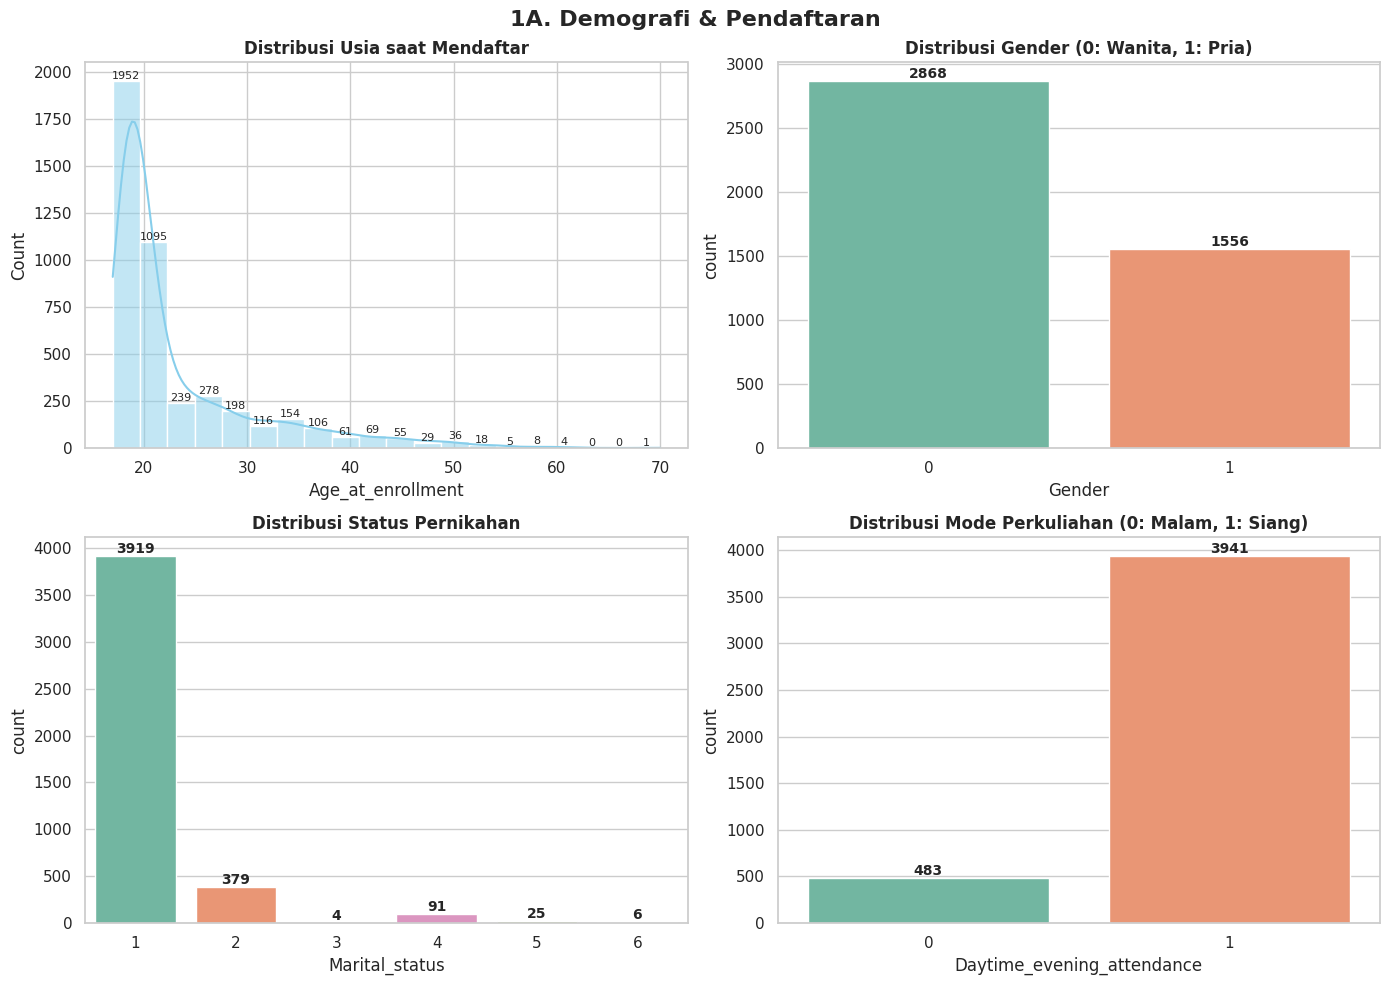

In [19]:
# A. Variabel Demografi & Pendaftaran
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Age at enrollment (Histplot)
ax1 = sns.histplot(df['Age_at_enrollment'], kde=True, ax=axes[0, 0], color='skyblue', bins=20)
axes[0, 0].set_title('Distribusi Usia saat Mendaftar', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8)

# Gender
ax2 = sns.countplot(data=df, x='Gender', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Distribusi Gender (0: Wanita, 1: Pria)', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, fontweight='bold')

# Marital Status
ax3 = sns.countplot(data=df, x='Marital_status', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Distribusi Status Pernikahan', fontweight='bold')
for container in ax3.containers:
    ax3.bar_label(container, fontweight='bold')

# Daytime/Evening Attendance
ax4 = sns.countplot(data=df, x='Daytime_evening_attendance', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Distribusi Mode Perkuliahan (0: Malam, 1: Siang)', fontweight='bold')
for container in ax4.containers:
    ax4.bar_label(container, fontweight='bold')

plt.suptitle('1A. Demografi & Pendaftaran', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

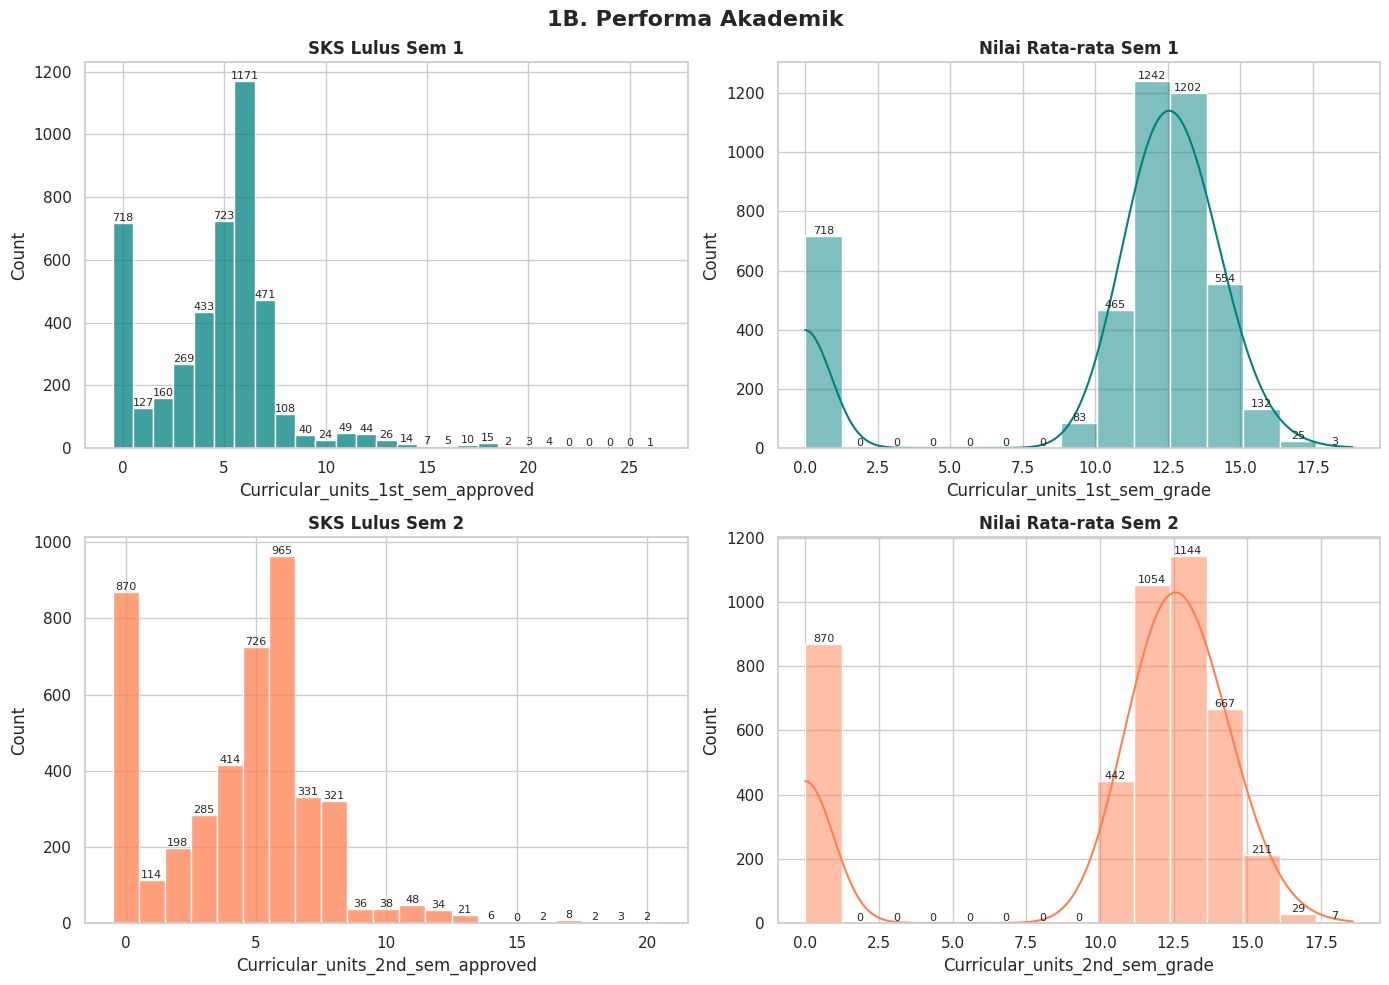

In [20]:
# B. Performa Variabel Akademik
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# SKS Lulus Sem 1
ax1 = sns.histplot(df['Curricular_units_1st_sem_approved'], kde=False, ax=axes[0, 0], color='teal', discrete=True)
axes[0, 0].set_title('SKS Lulus Sem 1', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, fontsize=8)

# Nilai Rata-rata Sem 1
ax2 = sns.histplot(df['Curricular_units_1st_sem_grade'], kde=True, ax=axes[0, 1], color='teal', bins=15)
axes[0, 1].set_title('Nilai Rata-rata Sem 1', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, fontsize=8)

# SKS Lulus Sem 2
ax3 = sns.histplot(df['Curricular_units_2nd_sem_approved'], kde=False, ax=axes[1, 0], color='coral', discrete=True)
axes[1, 0].set_title('SKS Lulus Sem 2', fontweight='bold')
for container in ax3.containers:
    ax3.bar_label(container, fontsize=8)

# Nilai Rata-rata Sem 2
ax4 = sns.histplot(df['Curricular_units_2nd_sem_grade'], kde=True, ax=axes[1, 1], color='coral', bins=15)
axes[1, 1].set_title('Nilai Rata-rata Sem 2', fontweight='bold')
for container in ax4.containers:
    ax4.bar_label(container, fontsize=8)

plt.suptitle('1B. Performa Akademik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_963/2341891101.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(data=df, x='Scholarship_holder', ax=axes[0], palette='Set2')
/tmp/ipykernel_963/2341891101.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(data=df, x='Tuition_fees_up_to_date', ax=axes[1], palette='Set2')


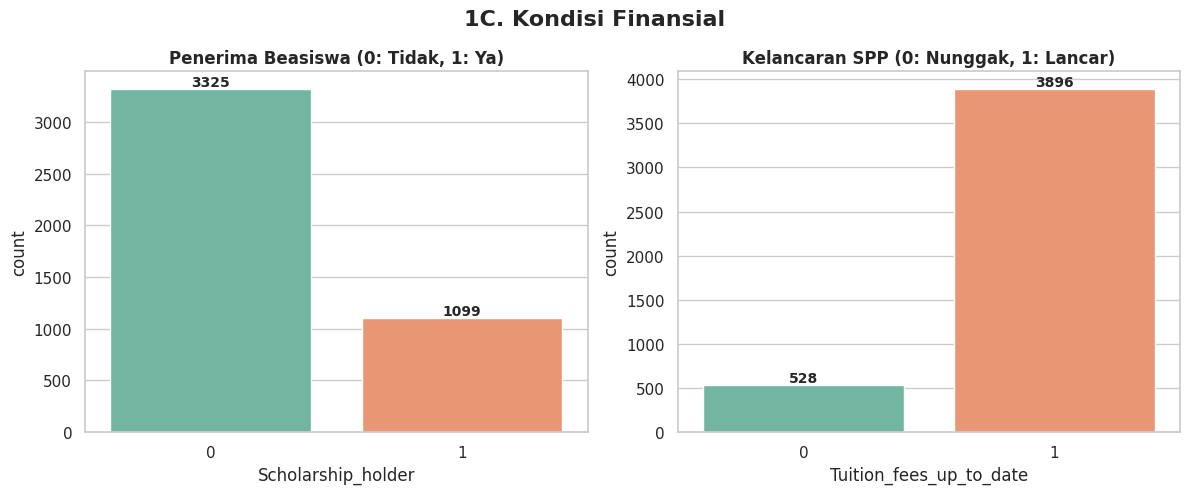

In [21]:
# C. Kondisi Finansial
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scholarship holder
ax1 = sns.countplot(data=df, x='Scholarship_holder', ax=axes[0], palette='Set2')
axes[0].set_title('Penerima Beasiswa (0: Tidak, 1: Ya)', fontweight='bold')
for container in ax1.containers:
    ax1.bar_label(container, fontweight='bold')

# Tuition fees up to date
ax2 = sns.countplot(data=df, x='Tuition_fees_up_to_date', ax=axes[1], palette='Set2')
axes[1].set_title('Kelancaran SPP (0: Nunggak, 1: Lancar)', fontweight='bold')
for container in ax2.containers:
    ax2.bar_label(container, fontweight='bold')

plt.suptitle('1C. Kondisi Finansial', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Ringkasan dari Analisis Univariat

Berdasarkan dari visualisasi di atas, ini ada beberapa poin yang bisa kita ambil:

##### 1. Variabel Demografi & Pendaftaran
* **Usia Mendaftar:** Sebagian besar mahasiswa masuk di usia muda (18–20 tahun). Tapi kalau dilihat lagi, ada juga mahasiswa usia dewasa sampai umur 40 tahun ke atas meski jumlahnya sedikit.
* **Gender:** Jumlah mahasiswa perempuan jauh lebih banyak (2.868 orang) dibandingkan mahasiswa laki-laki (1.556 orang).
* **Status Pernikahan:** Hampir semua mahasiswa statusnya belum menikah (3.919 orang).
* **Mode Perkuliahan:** Mayoritas memilih kelas Siang (3.941 orang), sedangkan yang mengambil kelas Malam hanya 483 orang.

---

##### 2. Performa Variabel Akademik
* **Jumlah SKS Lulus:** Kebanyakan mahasiswa berhasil lulus 6 mata kuliah/SKS di Semester 1 maupun Semester 2.
* **Ada yang 0 SKS:** Berdasarkan dari visualisasi tersebut, ada **718 mahasiswa di Semester 1** dan naik menjadi **870 mahasiswa di Semester 2** yang **tidak lulus SKS sama sekali (0 SKS)**. Kelompok inilah yang sangat rawan *dropout*.
* **Nilai Rata-rata:** Mahasiswa yang aktif rata-rata punya nilai di kisaran 10–15. Lonjakan di angka `0.0` sejajar dengan banyaknya mahasiswa yang tidak lulus SKS tadi.

---

##### 3. Kondisi Finansial
* **Penerima Beasiswa:** Sebagian besar mahasiswa tidak menerima beasiswa (3.325 orang). Hanya sekitar 25% (1.099 orang) yang dapat beasiswa.
* **Tunggakan SPP:** Walau mayoritas bayarnya lancar, ada **528 mahasiswa yang menunggak SPP**. Kelompok ini perlu diperhatikan karena masalah keuangan sering jadi pemicu utama mahasiswa berhenti kuliah.

### 2. Analisis Bivariat

/tmp/ipykernel_963/2030081042.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Tidak Punya Hutang', 'Punya Hutang'])
/tmp/ipykernel_963/2030081042.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Nunggak', 'Lancar'])
/tmp/ipykernel_963/2030081042.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Bukan Beasiswa', 'Penerima Beasiswa'])


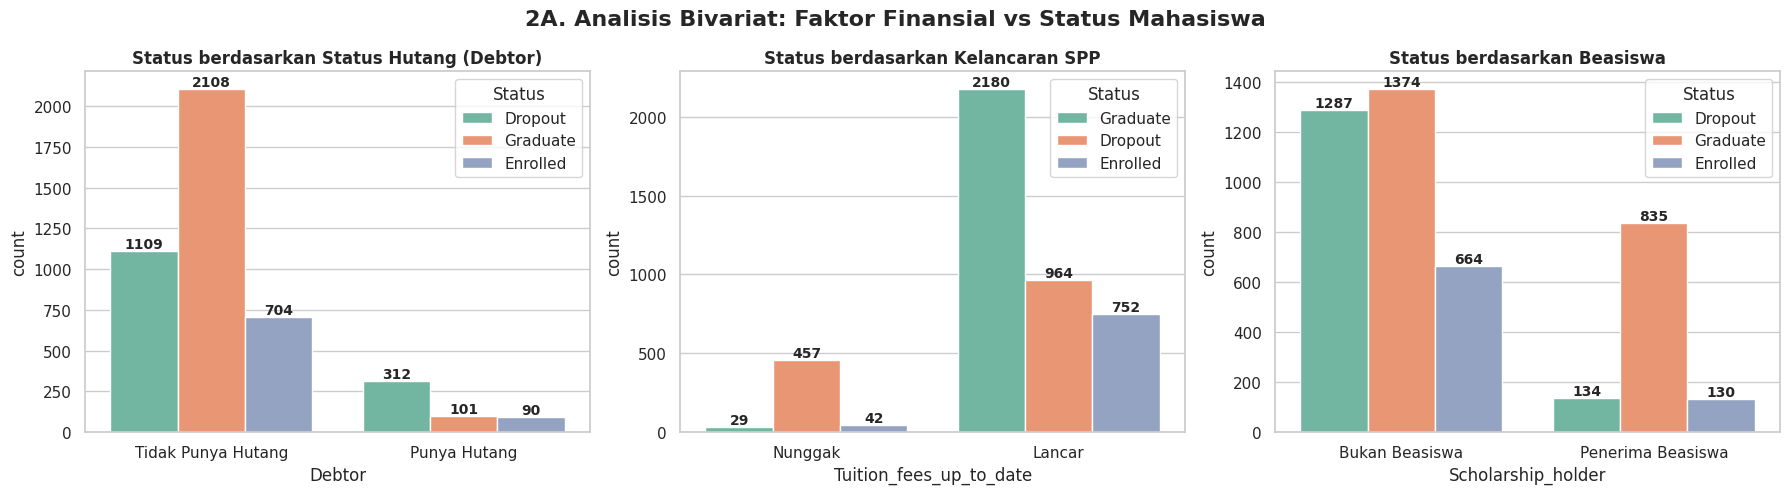

In [22]:
# BIVARIAT: FAKTOR FINANSIAL VS STATUS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Punya Hutang (Debtor) vs Status
ax1 = sns.countplot(data=df, x='Debtor', hue='Status', ax=axes[0], palette='Set2')
axes[0].set_title('Status berdasarkan Status Hutang (Debtor)', fontweight='bold')
axes[0].set_xticklabels(['Tidak Punya Hutang', 'Punya Hutang'])
for container in ax1.containers:
    ax1.bar_label(container, fontweight='bold')

# 2. Kelancaran SPP vs Status
ax2 = sns.countplot(data=df, x='Tuition_fees_up_to_date', hue='Status', ax=axes[1], palette='Set2')
axes[1].set_title('Status berdasarkan Kelancaran SPP', fontweight='bold')
axes[1].set_xticklabels(['Nunggak', 'Lancar'])
for container in ax2.containers:
    ax2.bar_label(container, fontweight='bold')

# 3. Penerima Beasiswa vs Status
ax3 = sns.countplot(data=df, x='Scholarship_holder', hue='Status', ax=axes[2], palette='Set2')
axes[2].set_title('Status berdasarkan Beasiswa', fontweight='bold')
axes[2].set_xticklabels(['Bukan Beasiswa', 'Penerima Beasiswa'])
for container in ax3.containers:
    ax3.bar_label(container, fontweight='bold')

plt.suptitle('2A. Analisis Bivariat: Faktor Finansial vs Status Mahasiswa', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_963/2449939276.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Age_at_enrollment', ax=axes[0], palette='Set2')
/tmp/ipykernel_963/2449939276.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Wanita', 'Pria'])
/tmp/ipykernel_963/2449939276.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Malam', 'Siang'])


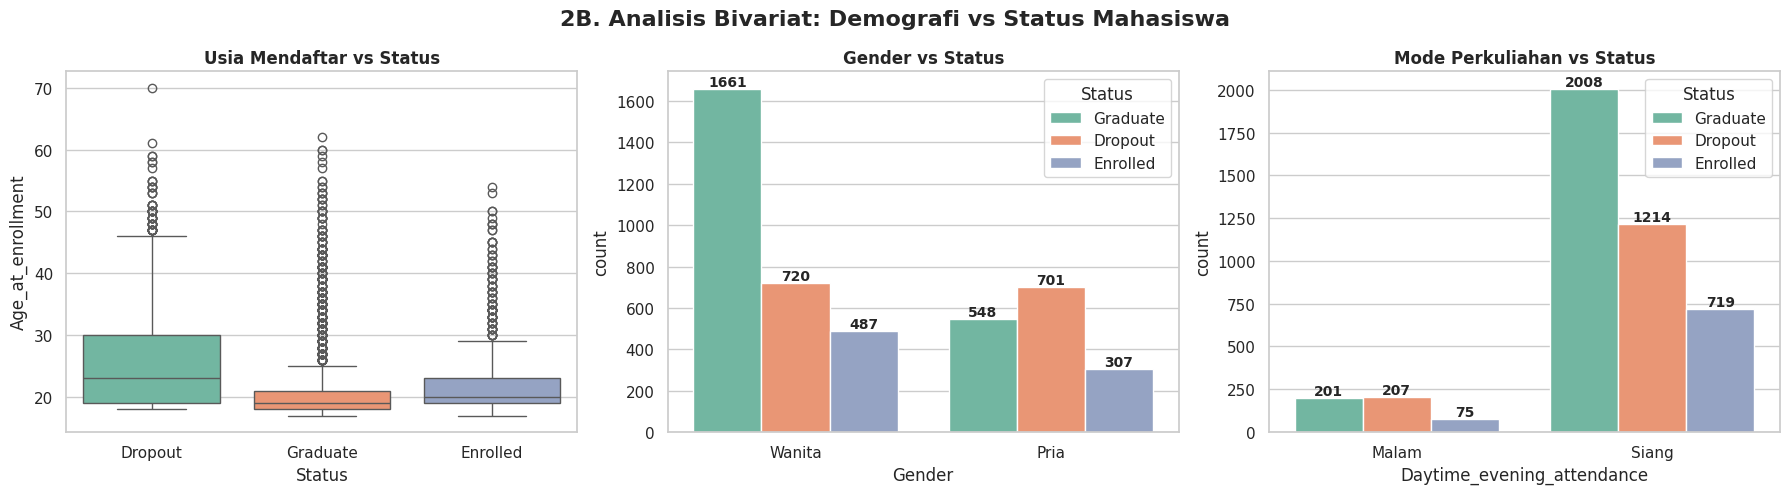

In [23]:
# BIVARIAT: DEMOGRAFI & JALUR MASUK VS STATUS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Usia saat Mendaftar vs Status (Boxplot untuk melihat distribusi)
sns.boxplot(data=df, x='Status', y='Age_at_enrollment', ax=axes[0], palette='Set2')
axes[0].set_title('Usia Mendaftar vs Status', fontweight='bold')

# 2. Gender vs Status
ax2 = sns.countplot(data=df, x='Gender', hue='Status', ax=axes[1], palette='Set2')
axes[1].set_title('Gender vs Status', fontweight='bold')
axes[1].set_xticklabels(['Wanita', 'Pria'])
for container in ax2.containers:
    ax2.bar_label(container, fontweight='bold')

# 3. Mode Perkuliahan vs Status
ax3 = sns.countplot(data=df, x='Daytime_evening_attendance', hue='Status', ax=axes[2], palette='Set2')
axes[2].set_title('Mode Perkuliahan vs Status', fontweight='bold')
axes[2].set_xticklabels(['Malam', 'Siang'])
for container in ax3.containers:
    ax3.bar_label(container, fontweight='bold')

plt.suptitle('2B. Analisis Bivariat: Demografi vs Status Mahasiswa', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_963/4038448482.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', ax=axes[0, 0], palette='Set2')
/tmp/ipykernel_963/4038448482.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', ax=axes[0, 1], palette='Set2')
/tmp/ipykernel_963/4038448482.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', ax=axes[1, 0], palette='Set2')
/tmp/ipykernel_963/4038448482.

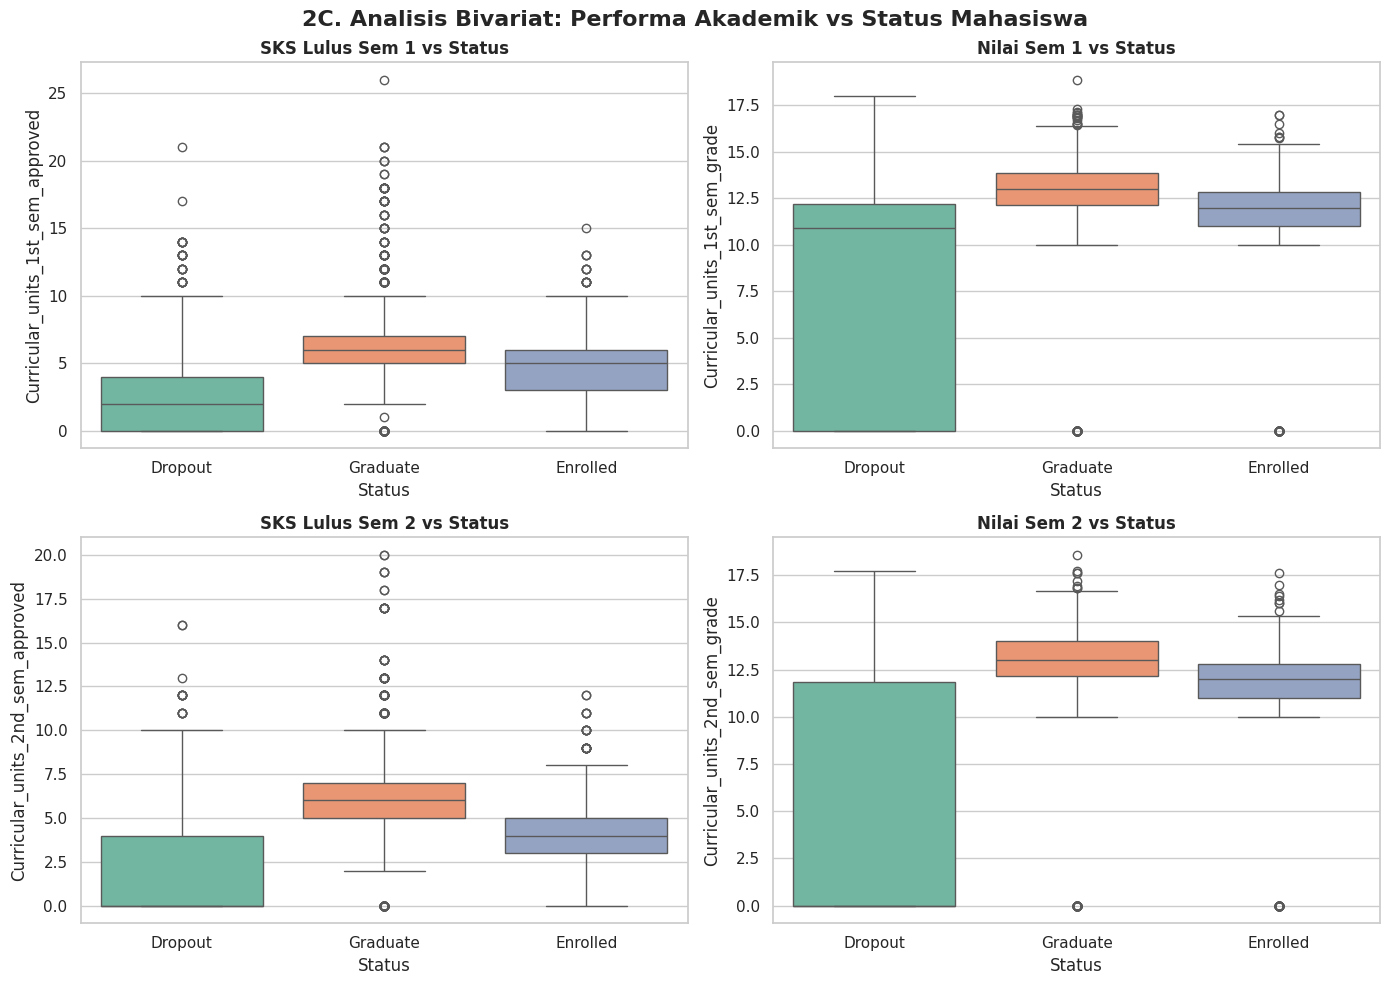

In [24]:
# BIVARIAT: PERFORMA AKADEMIK VS STATUS
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. SKS Lulus Sem 1 vs Status
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_approved', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('SKS Lulus Sem 1 vs Status', fontweight='bold')

# 2. Nilai Sem 1 vs Status
sns.boxplot(data=df, x='Status', y='Curricular_units_1st_sem_grade', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Nilai Sem 1 vs Status', fontweight='bold')

# 3. SKS Lulus Sem 2 vs Status
sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_approved', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('SKS Lulus Sem 2 vs Status', fontweight='bold')

# 4. Nilai Sem 2 vs Status
sns.boxplot(data=df, x='Status', y='Curricular_units_2nd_sem_grade', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Nilai Sem 2 vs Status', fontweight='bold')

plt.suptitle('2C. Analisis Bivariat: Performa Akademik vs Status Mahasiswa', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

#### Ringkasan dari Analisis Bivariat

Berdasarkan dari visualisasi di atas, ini ada beberapa poin mengenai hubungan berbagai faktor terhadap status mahasiswa (Graduate, Dropout, atau Enrolled):

##### 1. Faktor Finansial vs Status Mahasiswa
* **Kelancaran SPP:** Berdasarkan dari visualisasi tersebut, mahasiswa yang menunggak SPP mayoritas berakhir **Dropout** (457 orang) dibandingkan yang berhasil Graduate (29 orang). Sebaliknya, mahasiswa yang SPP-nya lancar dominan **Graduate** (2.180 orang).
* **Penerima Beasiswa:** Mahasiswa penerima beasiswa punya peluang lulus jauh lebih tinggi. Tercatat ada 835 orang berhasil Graduate dan hanya 134 orang yang Dropout.
* **Status Hutang (Debtor):** Mahasiswa yang punya hutang cenderung lebih rentan Dropout (312 orang) dibanding Graduate (101 orang).

---

##### 2. Demografi & Perkuliahan vs Status Mahasiswa
* **Usia Mendaftar:** Berdasarkan dari visualisasi tersebut, mahasiswa yang lulus (Graduate) rata-rata mendaftar di usia lebih muda (sekitar 18–20 tahun). Sebaliknya, kelompok mahasiswa Dropout punya rentang usia yang lebih lebar dan sebarannya cenderung di usia yang lebih tua.
* **Gender:** Mahasiswa perempuan punya persentase kelulusan yang jauh lebih tinggi (1.661 Graduate) daripada jumlah yang Dropout (720 orang). Sementara pada mahasiswa laki-laki, jumlah yang Dropout (701 orang) justru lebih banyak daripada yang Graduate (548 orang).
* **Mode Perkuliahan:** Mahasiswa kelas Malam punya rasio Dropout yang sedikit lebih tinggi dibanding Graduate (207 Dropout vs 201 Graduate), sedangkan kelas Siang didominasi oleh mahasiswa yang Graduate (2.008 orang).

---

##### 3. Performa Akademik vs Status Mahasiswa
* **Jumlah SKS Lulus (Sem 1 & Sem 2):** Berdasarkan dari visualisasi tersebut, mahasiswa yang Graduate konsisten meluluskan 5–7 mata kuliah/SKS per semester. Sedangkan mahasiswa Dropout mayoritas hanya meluluskan 0–4 SKS.
* **Nilai Rata-rata (Grade Sem 1 & Sem 2):** Mahasiswa yang lulus memiliki nilai rata-rata yang stabil di atas angka 12–14. Sebaliknya, kelompok Dropout memiliki sebaran nilai yang sangat rendah, bahkan terbanyak menumpuk di angka `0`.

### 3. Analisis Multivariat

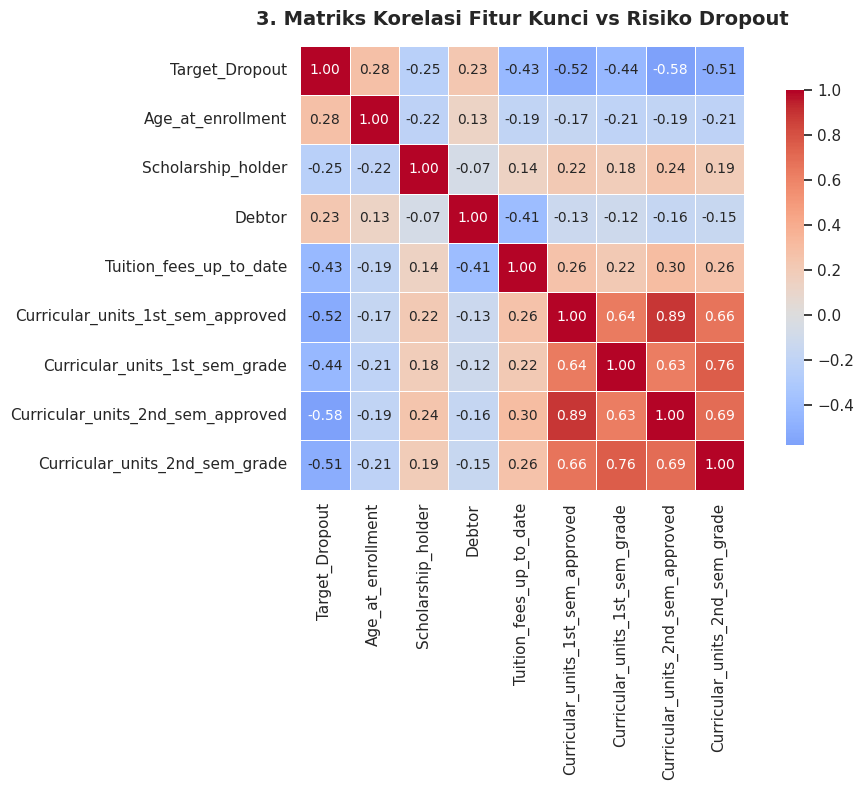

In [25]:
# ANALISIS MULTIVARIAT: CORRELATION HEATMAP
# 1. Buat salinan dataframe untuk matriks korelasi
df_corr = df.copy()

# 2. Mapping variabel Status ke numerik (fokus pada Dropout vs Non-Dropout / Graduate)
# Petakan: Dropout = 1, Graduate = 0, Enrolled = 0
status_map = {'Dropout': 1, 'Enrolled': 0, 'Graduate': 0}
if df_corr['Status'].dtype == 'object':
    df_corr['Target_Dropout'] = df_corr['Status'].map(status_map)

# 3. Pilih fitur-fitur kunci yang akan dianalisis korelasinya
selected_features = [
    'Target_Dropout',
    'Age_at_enrollment',
    'Scholarship_holder',
    'Debtor',
    'Tuition_fees_up_to_date',
    'Curricular_units_1st_sem_approved',
    'Curricular_units_1st_sem_grade',
    'Curricular_units_2nd_sem_approved',
    'Curricular_units_2nd_sem_grade'
]

# Hitung matriks korelasi Spearman (ini cocok untuk variabel campuran numerik & ordinal)
corr_matrix = df_corr[selected_features].corr(method='spearman')

# Plot Heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8}
)

plt.title('3. Matriks Korelasi Fitur Kunci vs Risiko Dropout', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

#### Ringkasan dari Analisis Multivariat

Berdasarkan dari visualisasi di atas, dapat kita amati (fokus ke **Target_Dropout**) bahwa:

##### 1. Faktor Penurun Risiko Dropout (Angka Minus / Berwarna Biru)
* **Performa Akademik (Paling Dominan):** SKS yang lulus di Semester 2 (`-0.58`) dan Semester 1 (`-0.52`), serta Nilai rata-rata Semester 2 (`-0.51`) dan Semester 1 (`-0.44`). Berdasarkan dari visualisasi tersebut, semakin banyak SKS yang lulus dan semakin tinggi juga nilainya, maka semakin kecil risiko mahasiswa untuk *dropout*.
* **Kelancaran SPP & Beasiswa:** Kelancaran bayar SPP (`-0.43`) dan status beasiswa (`-0.25`) juga terbukti efektif menurunkan risiko *dropout*.

---

##### 2. Faktor Pemicu Risiko Dropout (Angka Plus / Berwarna Merah Muda)
* **Usia Mendaftar:** Berdasarkan dari visualisasi tersebut, usia saat mendaftar (`+0.28`) menunjukkan bahwa mahasiswa yang mendaftar di usia lebih tua punya risiko *dropout* yang sedikit lebih tinggi.
* **Tunggakan Utang:** Punya utang (`Debtor` di angka `+0.23`) ikut mendorong peningkatan risiko mahasiswa untuk berhenti kuliah.

## Unggah ke Supabase

## Modeling

## Evaluation